## **<font color="red">Effect of Degree</font>**
### **degree = 3**

Training samples: 64, Test samples: 16

Train R²: 0.7478, Train MSE: 338.8234
Test  R²: 0.7863, Test  MSE: 312.3776

Learned model:
y = -4.7444 + (8.6194)*x^1 + (-1.1728)*x^2 + (1.6293)*x^3


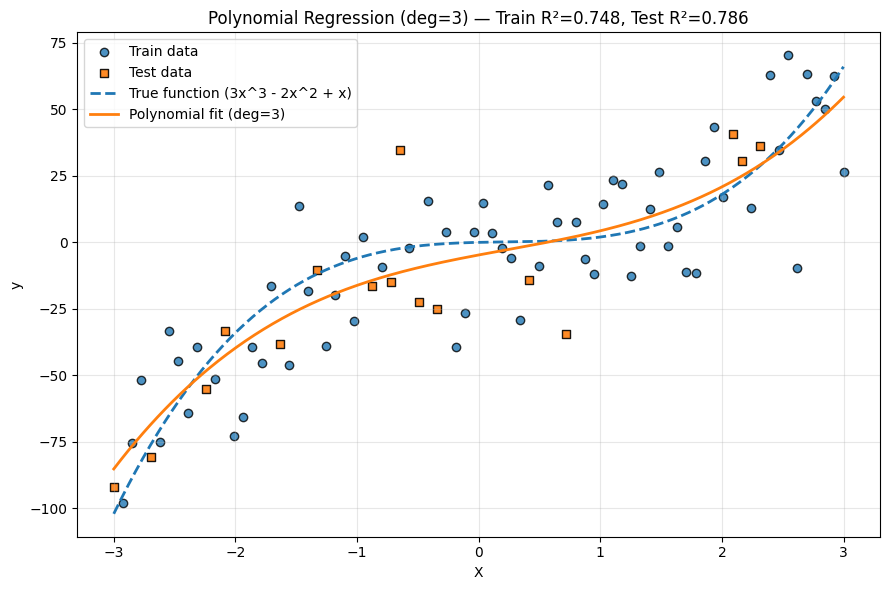

In [4]:
# Polynomial regression with proper train/test split (step-wise)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)

# Inputs
X = np.linspace(-3, 3, 80).reshape(-1, 1)    # shape (80,1)

# True cubic function
true_y = (3 * X**3 - 2 * X**2 + X).ravel()  # ravel -> shape (80,)

# Add stronger Gaussian noise
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise                           # final observations (80,)

# -----------------------------
# 2. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 3. Polynomial features (fit on train only)
# -----------------------------
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training data, then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # shape (n_train, degree)
X_test_poly = poly.transform(X_test)         # shape (n_test, degree)

# -----------------------------
# 4. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()  # coefs correspond to x^1, x^2, ..., x^degree (since include_bias=False)

terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Create a dense X for smooth plotting of true function and model prediction
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()

# Transform X_plot using the same poly transformer
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **degree = 5**

Training samples: 64, Test samples: 16

Train R²: 0.7514, Train MSE: 334.0023
Test  R²: 0.7910, Test  MSE: 305.5132

Learned model:
y = -3.7919 + (4.0728)*x^1 + (-2.0188)*x^2 + (3.9961)*x^3 + (0.1129)*x^4 + (-0.2355)*x^5


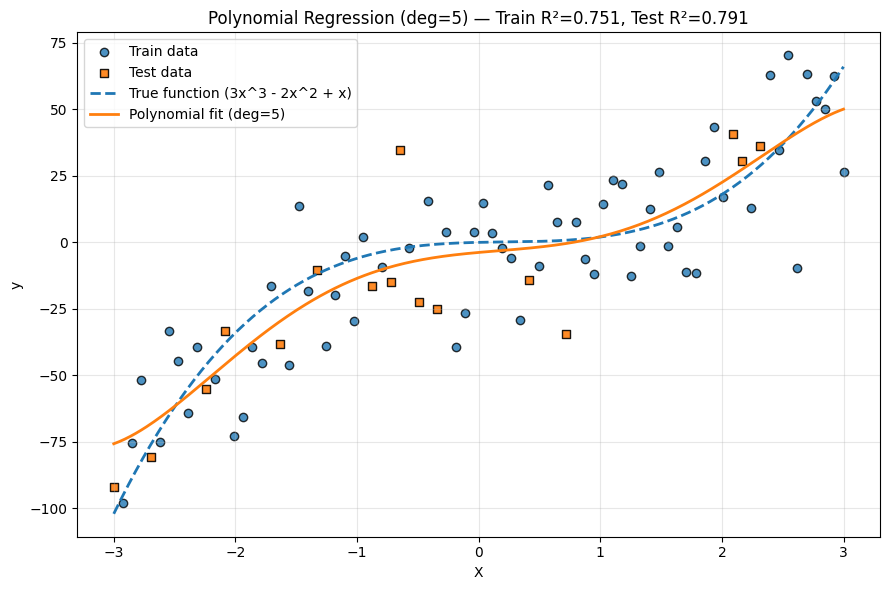

In [5]:
# Polynomial regression with proper train/test split (step-wise)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)

# Inputs
X = np.linspace(-3, 3, 80).reshape(-1, 1)    # shape (80,1)

# True cubic function
true_y = (3 * X**3 - 2 * X**2 + X).ravel()  # ravel -> shape (80,)

# Add stronger Gaussian noise
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise                           # final observations (80,)

# -----------------------------
# 2. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 3. Polynomial features (fit on train only)
# -----------------------------
degree = 5
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training data, then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # shape (n_train, degree)
X_test_poly = poly.transform(X_test)         # shape (n_test, degree)

# -----------------------------
# 4. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()  # coefs correspond to x^1, x^2, ..., x^degree (since include_bias=False)

terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Create a dense X for smooth plotting of true function and model prediction
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()

# Transform X_plot using the same poly transformer
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **degree=8**

Training samples: 64, Test samples: 16

Train R²: 0.7750, Train MSE: 302.2150
Test  R²: 0.7341, Test  MSE: 388.6855

Learned model:
y = -5.5934 + (-0.1920)*x^1 + (12.3811)*x^2 + (8.5249)*x^3 + (-10.9028)*x^4 + (-1.4562)*x^5 + (2.3946)*x^6 + (0.0920)*x^7 + (-0.1541)*x^8


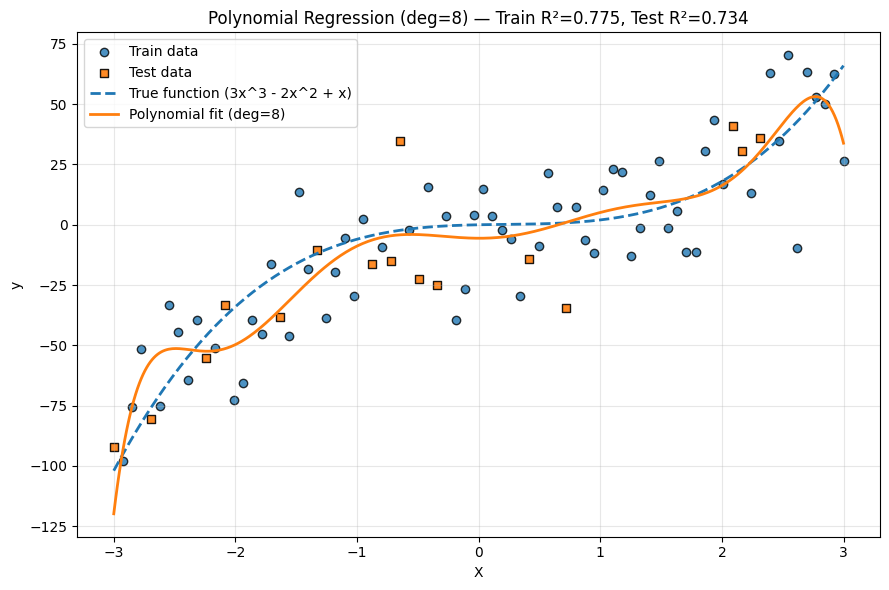

In [6]:
# Polynomial regression with proper train/test split (step-wise)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)

# Inputs
X = np.linspace(-3, 3, 80).reshape(-1, 1)    # shape (80,1)

# True cubic function
true_y = (3 * X**3 - 2 * X**2 + X).ravel()  # ravel -> shape (80,)

# Add stronger Gaussian noise
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise                           # final observations (80,)

# -----------------------------
# 2. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 3. Polynomial features (fit on train only)
# -----------------------------
degree = 8
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training data, then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # shape (n_train, degree)
X_test_poly = poly.transform(X_test)         # shape (n_test, degree)

# -----------------------------
# 4. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()  # coefs correspond to x^1, x^2, ..., x^degree (since include_bias=False)

terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Create a dense X for smooth plotting of true function and model prediction
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()

# Transform X_plot using the same poly transformer
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **degree = 10**

Training samples: 64, Test samples: 16

Train R²: 0.7780, Train MSE: 298.2619
Test  R²: 0.6601, Test  MSE: 496.7205

Learned model:
y = -5.7143 + (8.1685)*x^1 + (10.7647)*x^2 + (-4.5203)*x^3 + (-8.6810)*x^4 + (4.1785)*x^5 + (1.5027)*x^6 + (-0.8050)*x^7 + (-0.0154)*x^8 + (0.0473)*x^9 + (-0.0073)*x^10


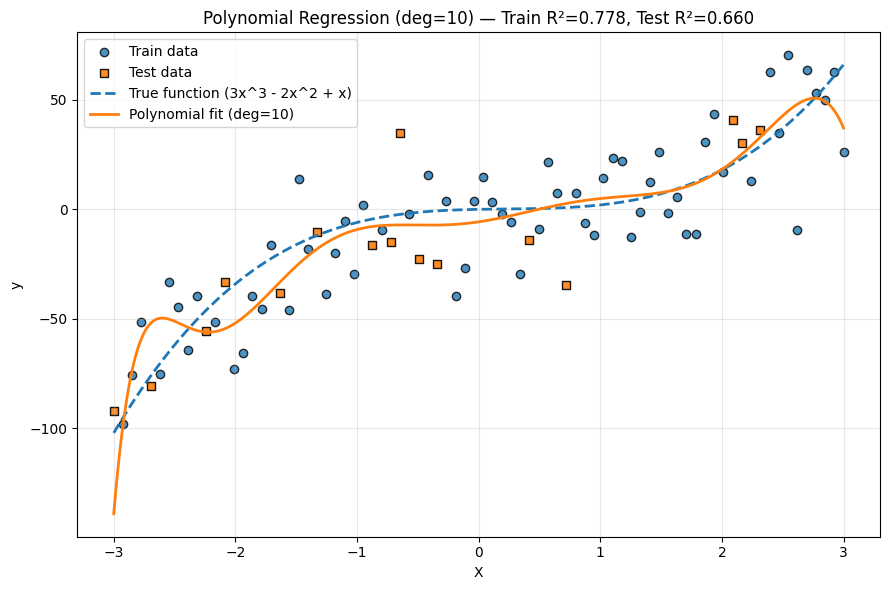

In [7]:
# Polynomial regression with proper train/test split (step-wise)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)

# Inputs
X = np.linspace(-3, 3, 80).reshape(-1, 1)    # shape (80,1)

# True cubic function
true_y = (3 * X**3 - 2 * X**2 + X).ravel()  # ravel -> shape (80,)

# Add stronger Gaussian noise
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise                           # final observations (80,)

# -----------------------------
# 2. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 3. Polynomial features (fit on train only)
# -----------------------------
degree = 10
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training data, then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # shape (n_train, degree)
X_test_poly = poly.transform(X_test)         # shape (n_test, degree)

# -----------------------------
# 4. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()  # coefs correspond to x^1, x^2, ..., x^degree (since include_bias=False)

terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Create a dense X for smooth plotting of true function and model prediction
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()

# Transform X_plot using the same poly transformer
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **degree = 15**

Training samples: 64, Test samples: 16

Train R²: 0.7896, Train MSE: 282.6162
Test  R²: 0.6760, Test  MSE: 473.5489

Learned model:
y = -4.7790 + (-9.8372)*x^1 + (-3.9635)*x^2 + (61.2559)*x^3 + (23.0463)*x^4 + (-64.9489)*x^5 + (-23.1176)*x^6 + (30.7928)*x^7 + (8.8249)*x^8 + (-7.2463)*x^9 + (-1.5973)*x^10 + (0.8857)*x^11 + (0.1391)*x^12 + (-0.0536)*x^13 + (-0.0047)*x^14 + (0.0013)*x^15


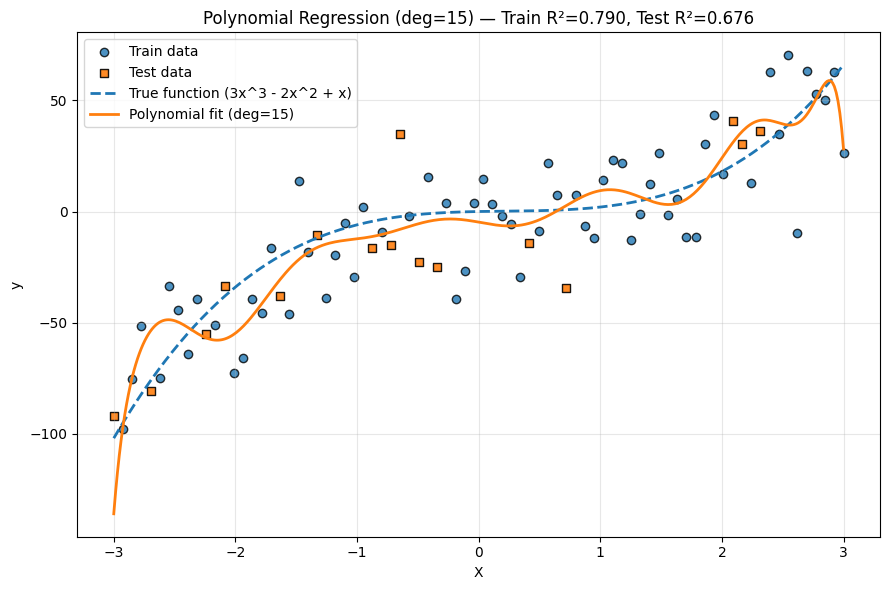

In [8]:
# Polynomial regression with proper train/test split (step-wise)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)

# Inputs
X = np.linspace(-3, 3, 80).reshape(-1, 1)    # shape (80,1)

# True cubic function
true_y = (3 * X**3 - 2 * X**2 + X).ravel()  # ravel -> shape (80,)

# Add stronger Gaussian noise
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise                           # final observations (80,)

# -----------------------------
# 2. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 3. Polynomial features (fit on train only)
# -----------------------------
degree = 15
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training data, then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # shape (n_train, degree)
X_test_poly = poly.transform(X_test)         # shape (n_test, degree)

# -----------------------------
# 4. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()  # coefs correspond to x^1, x^2, ..., x^degree (since include_bias=False)

terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Create a dense X for smooth plotting of true function and model prediction
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()

# Transform X_plot using the same poly transformer
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
